# Hillside Avenue Bus Lane — Pre / Post Survey Analysis
### Comparing the 2024 and 2026 post-implementation intercept surveys

This notebook walks through the comparative analysis of two NYC DOT intercept
surveys about the Hillside Avenue bus lane:

- **2024** — earlier post-implementation wave (440 respondents)
- **2026** — later post-implementation wave (385 respondents)

The two SurveyMonkey exports **do not use identical wording or answer
choices**, so a big part of the work is *harmonizing* them onto a shared schema
and only comparing questions that are genuinely pre/post comparable. That logic
lives in **`survey_lib.py`** (imported below); this notebook is the readable,
shareable narrative on top of it.

**To run this notebook you need** (all in the same folder):
`survey_lib.py`, `hillside2024.csv`, `hillside2026.csv`.
Install requirements with `pip install pandas matplotlib`.

---


## 1 · Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import survey_lib as S               # harmonization + comparison logic

%matplotlib inline
plt.rcParams.update({"figure.figsize": (9, 4.6), "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
C24, C26 = "#096495", "#E88024"       # 2024 = blue, 2026 = orange (DOT palette)
YEARS = S.YEARS

df = S.load_all()                     # tidy, harmonized, one row per respondent
print("Respondents:", {y: int((df.year == y).sum()) for y in YEARS})
df.head(3)

Respondents: {2024: 440, 2026: 385}


,year,respondent_id,often,howget,dur,sat,sat_score,issue,parked,findspot,...,age,eff,lang,zip,why,modes,buslines,gender,race,buslines_norm
0,2024,114638722803,Daily,Walk,1 - 15 minutes,None,NaN,None,None,None,...,45-54,Effective- Captured most of what I had to say,en,11423,(Work),"(Bus, Personal car)",(),(Man),(Hispanic or Latino),()
1,2024,114638021203,Daily,Bus,16 - 30 minutes,Neutral,3.0,Bus was slow,None,None,...,18-24,Effective- Captured most of what I had to say,en,11428,"(Shopping/Dining, Transit transfer/Passing thr...","(Subway, Bus, Personal car)",(Q36),(Man),(Asian),(Q36)
2,2024,114633289942,Daily,Bus,1 - 15 minutes,Neutral,3.0,Waited too long for the bus,None,None,...,35-44,Ineffective- Did not capture most what I had t...,en,11423,(Live here),"(Subway, Bus, Walk)",(Q76),(Man),(White),(Q76)


## 2 · Methodology — aligning two non-identical surveys

`survey_lib` maps both exports onto one schema by **column position** (stable
even when question wording drifts), then harmonizes the values:

| Field | 2024 form | 2026 form | Harmonization |
|---|---|---|---|
| **Satisfaction** | `1 - Very dissatisfied … 5` | label only | mapped to a common 1–5 scale |
| **Travel time** | free-text minutes | fixed buckets | 2024 parsed & binned into 2026's buckets |
| **Trip reason / modes** | some choices combined | split out | recombined (e.g. *Social/Recreational/Religious*) |
| **Gender** | Male / Female | Man / Woman | unified |
| **Age** | `65+` | `Over 65` | merged |

Percentages for single-answer questions are of respondents who answered *that*
question that year; multi-select percentages are of respondents who made ≥1
selection and can exceed 100%. Questions asked in only one year are excluded.


## 3 · Respondents & base sizes

Different questions were routed to different people, so the **base `n` varies a
lot** — parking questions in particular were answered by only a few dozen
people. Always read a comparison against its base.

In [2]:
rows = []
for key, label, kind in S.QUESTIONS:
    if kind in ("single", "scale"):
        n = S.compare_single(df, key).attrs["n"]
    elif kind == "multi":
        n = S.compare_multi(df, key).attrs["n"]
    elif kind == "buslines":
        n = S.compare_buslines(df).attrs["n"]
    else:
        sub = df[key]
        n = {y: int(df[df.year == y][key].dropna().ne("").sum()) for y in YEARS}
    rows.append({"Question": label, "n (2024)": n[2024], "n (2026)": n[2026]})
pd.DataFrame(rows)

,Question,n (2024),n (2026)
0,Bus trip satisfaction (1-5),176,148
1,Biggest issue with bus ride,176,148
2,Bus lines used — normalized (checkbox + write-...,173,148
3,Bus lines used today (raw checkboxes),176,148
4,How often visit Hillside Ave,440,385
5,How you got here today (mode),440,385
6,Modes typically used,440,385
7,Travel time to Hillside,390,385
8,Reason for visit today,440,385
9,Parked on Hillside Ave,33,50


## 4 · Bus-trip satisfaction — the headline

Asked only of respondents who rode the bus. **Net satisfaction** =
% Satisfied/Very-satisfied − % Dissatisfied/Very-dissatisfied (neutrals stay in
the base), ranging −100 to +100.

In [3]:
ns = S.net_satisfaction(df)
for y in YEARS:
    s = ns[y]
    print(f"{y}:  net {s['net']:+.0f}   mean {s['mean']:.2f}   "
          f"top-2 {s['top2']:.0f}%   bottom-2 {s['bottom2']:.0f}%   n={s['n']}")
print(f"\nNet satisfaction change 2024 -> 2026:  {ns['delta']:+.1f} points")

2024:  net +18   mean 3.26   top-2 45%   bottom-2 28%   n=176
2026:  net +41   mean 3.50   top-2 61%   bottom-2 20%   n=148

Net satisfaction change 2024 -> 2026:  +22.9 points


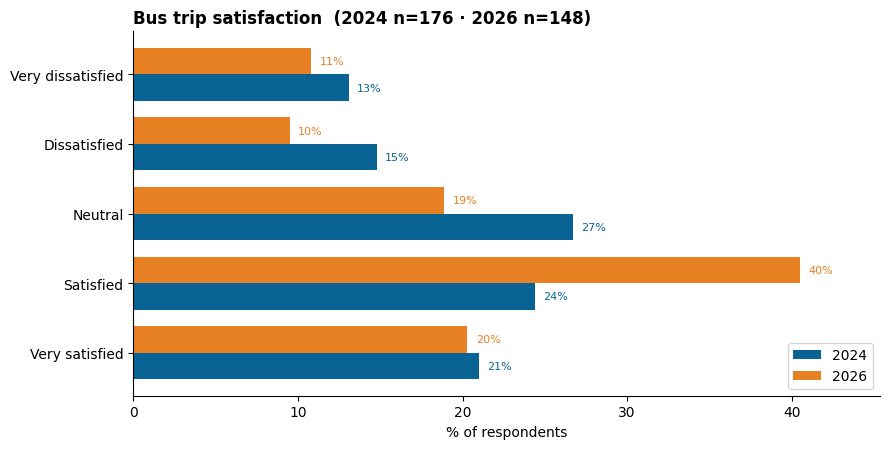

In [4]:
def plot_compare(cats, v24, v26, title, xlabel="% of respondents", figsize=(9, 4.6)):
    """Horizontal grouped bar: 2024 vs 2026. None values render as gaps."""
    a = [np.nan if v is None else v for v in v24]
    b = [np.nan if v is None else v for v in v26]
    y = np.arange(len(cats)); h = 0.38
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(y + h/2, a, h, color=C24, label="2024")
    ax.barh(y - h/2, b, h, color=C26, label="2026")
    for yi, v in zip(y + h/2, a):
        if not np.isnan(v): ax.text(v + 0.5, yi, f"{v:.0f}%", va="center", fontsize=8, color=C24)
    for yi, v in zip(y - h/2, b):
        if not np.isnan(v): ax.text(v + 0.5, yi, f"{v:.0f}%", va="center", fontsize=8, color=C26)
    ax.set_yticks(y); ax.set_yticklabels(cats); ax.invert_yaxis()
    ax.set_xlabel(xlabel); ax.set_title(title, fontweight="bold", loc="left")
    ax.legend(loc="lower right"); ax.margins(x=0.12)
    plt.tight_layout(); plt.show()

t = S.compare_single(df, "sat")
plot_compare(t["Category"], t["2024 %"], t["2026 %"],
             "Bus trip satisfaction  (2024 n=176 · 2026 n=148)")

**Takeaway.** Net satisfaction rose **+18 → +41** (a +23-point jump): the
Satisfied tier grew 24% → 40% while dissatisfaction fell 28% → 20%. This is the
clearest positive shift in the survey — but note the 2026 rider sample is older
and smaller (see §5), so pair the gain with the demographic caveat.

## 5 · Demographics — who responded (read with care)

These are shifts in *who answered*, not opinion changes. The 2026 sample skews
notably **older** (65+ went 14% → 24%), which matters before attributing any
trend to the bus lane itself.

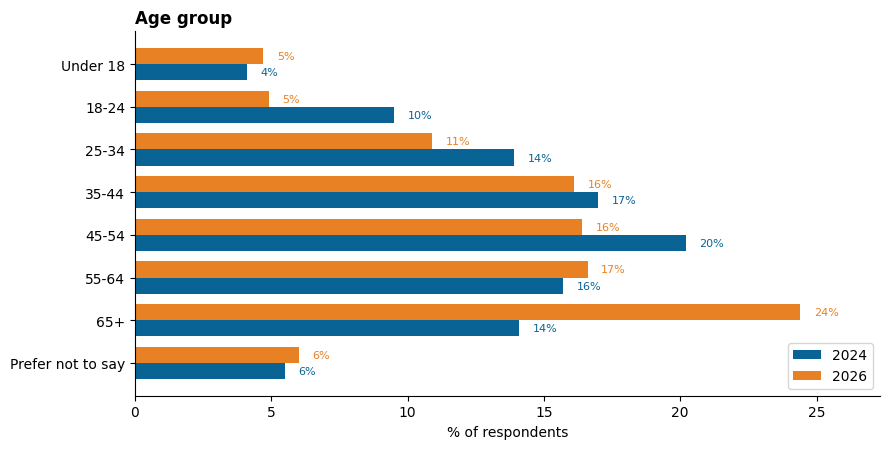

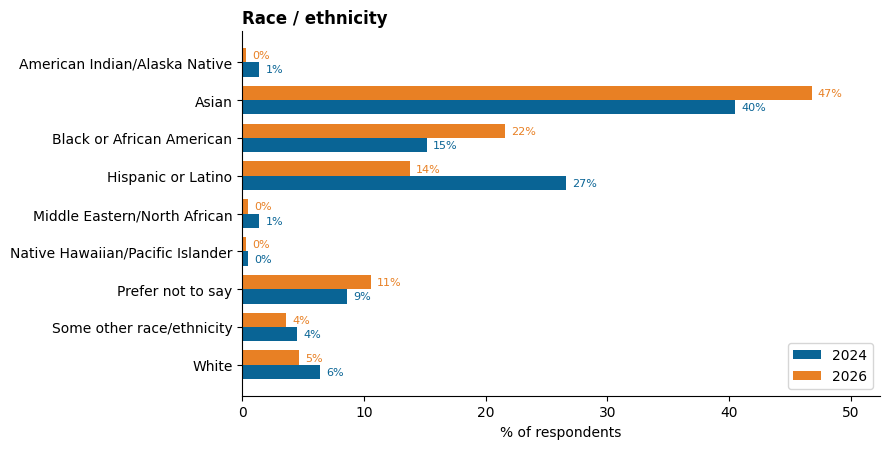

In [5]:
for key, title in [("age", "Age group"), ("race", "Race / ethnicity")]:
    t = S.compare_single(df, key) if S.QKIND[key] == "single" else S.compare_multi(df, key)
    col = "Category" if "Category" in t else "Option"
    plot_compare(t[col], t["2024 %"], t["2026 %"], title)

## 6 · Getting to Hillside — modes & travel time

Access stayed hyper-local and bus-dominated. Walking rose, subway use fell,
and trips of 16–30 min grew while sub-15-min trips held steady.

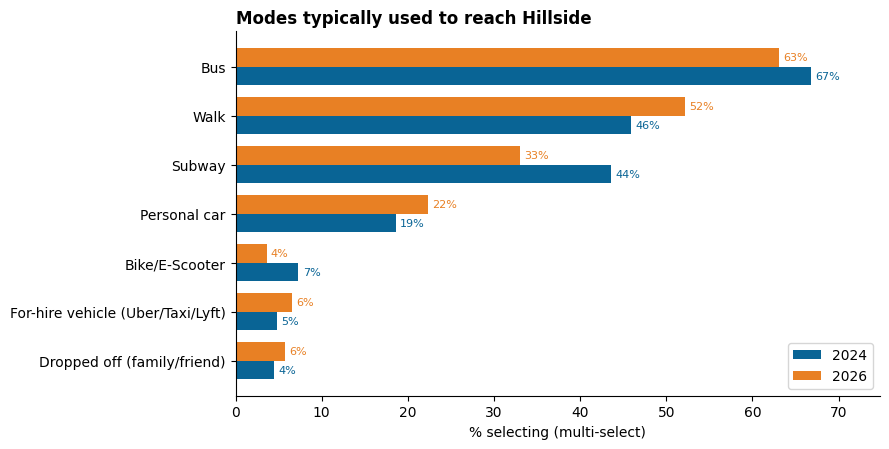

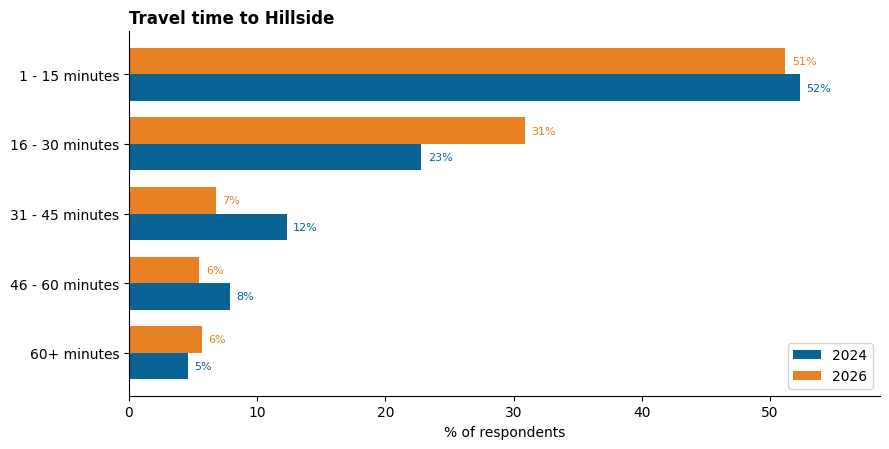

In [6]:
t = S.compare_multi(df, "modes")
order = ["Bus", "Walk", "Subway", "Personal car", "Bike/E-Scooter",
         "For-hire vehicle (Uber/Taxi/Lyft)", "Dropped off (family/friend)"]
idx = [t["Option"].tolist().index(o) for o in order]
plot_compare([t["Option"][i] for i in idx],
             [t["2024 %"][i] for i in idx], [t["2026 %"][i] for i in idx],
             "Modes typically used to reach Hillside", "% selecting (multi-select)")

d = S.compare_single(df, "dur")
plot_compare(d["Category"], d["2024 %"], d["2026 %"], "Travel time to Hillside")

## 7 · Bus lines — the "Other" problem, fixed

The survey's checkbox list only offered Q1/Q17/Q36/Q43/Q76/Q82/N6/N22/N24, so
**~40% of riders wrote their route into "Other."** Left as-is, that hides the
corridor's real routes. `compare_buslines()` parses the write-ins, folds
redundant Q43/Q17 write-ins back into their real totals, and marks checkbox
lines with `*`.

Raw "Other" bucket:  2024 46%   2026 35%   <- hides real routes


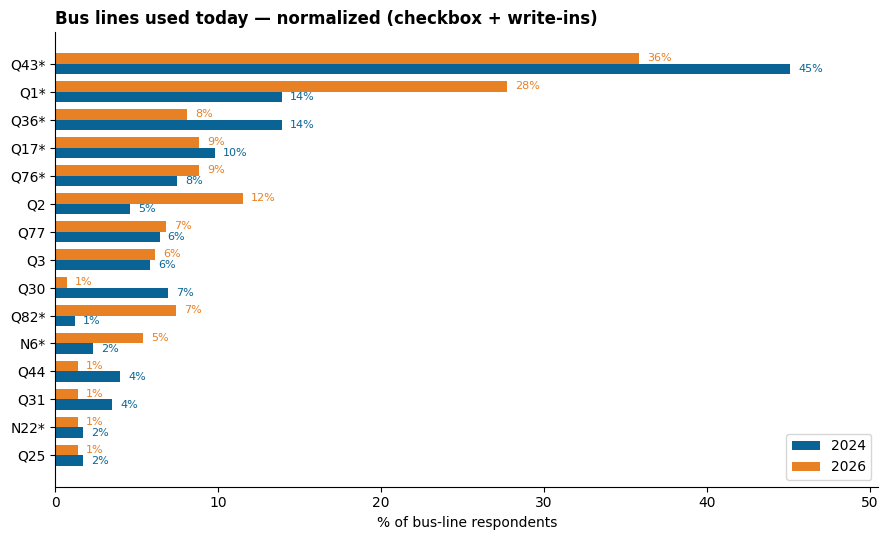

In [7]:
raw = S.compare_multi(df, "buslines")
o = raw[raw["Option"] == "Other"].iloc[0]
print(f'Raw "Other" bucket:  2024 {o["2024 %"]:.0f}%   2026 {o["2026 %"]:.0f}%   <- hides real routes')

bl = S.compare_buslines(df)
lines = bl[bl["Line"] != "Other lines (tail)"]
plot_compare(lines["Line"], lines["2024 %"], lines["2026 %"],
             "Bus lines used today — normalized (checkbox + write-ins)",
             "% of bus-line respondents", figsize=(9, 5.5))

**Takeaway.** Q1 usage nearly doubled (14% → 28%) and Q2 rose (5% → 12%),
while Q43 eased and Q30 nearly vanished — consistent with Queens bus-network
route changes between the two waves. Parsing write-ins shrank the unclassified
tail from ~24% to ~12%.

## 8 · Open-ended themes — "biggest transportation issue"

Free-text responses categorized by keyword theme (a response can match more than
one). The standout is **bus-lane backlash**: complaints tying congestion or
tickets to the bus lane itself jumped **4.5% → 20.9%** even as satisfaction rose.

Responses categorized:  2024 n=440   2026 n=339


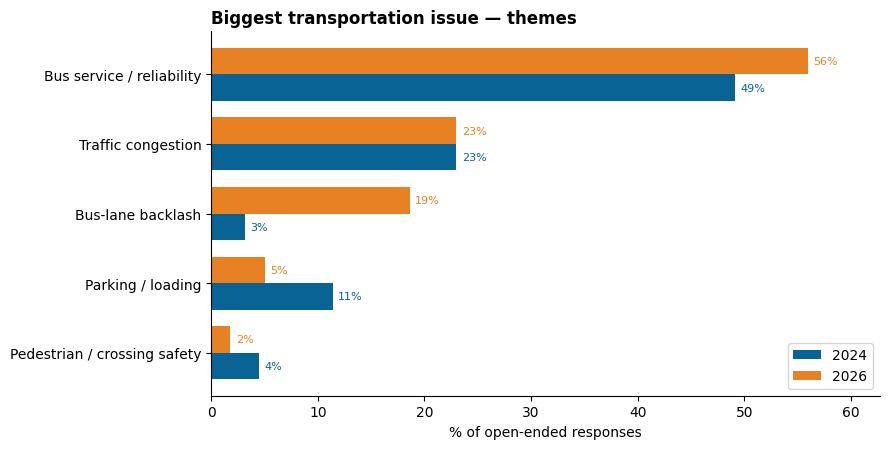

In [8]:
THEMES = [
    ("Bus service / reliability", ["bus", "wait", "reliab", "service", "frequen", "bunch"]),
    ("Traffic congestion", ["traffic", "congest", "backed up", "gridlock"]),
    ("Bus-lane backlash", ["bus lane", "one lane", "second lane", "ticket", "reduc", "took away"]),
    ("Parking / loading", ["park", "loading", "double park", "spot"]),
    ("Pedestrian / crossing safety", ["cross", "pedestrian", "crosswalk", "yield", "signal", "red light"]),
]
def theme_pct(y):
    txt = [t.strip() for t in df[df.year == y]["issue_text"].dropna() if t.strip()]
    tot = len(txt)
    return {name: round(100 * sum(any(k in t.lower() for k in kws) for t in txt) / tot, 1)
            for name, kws in THEMES}, tot

p24, n24 = theme_pct(2024); p26, n26 = theme_pct(2026)
print(f"Responses categorized:  2024 n={n24}   2026 n={n26}")
names = [t[0] for t in THEMES]
plot_compare(names, [p24[k] for k in names], [p26[k] for k in names],
             "Biggest transportation issue — themes", "% of open-ended responses")

In [9]:
# A few representative *verbatim* responses (unedited)
for q in ["Bus service is irregular.", "Bus lanes cause congestion.",
          "Too much traffic, double parking", "A lot of car traffic"]:
    print("•", q)

• Bus service is irregular.
• Bus lanes cause congestion.
• Too much traffic, double parking
• A lot of car traffic


## 9 · Explore any question yourself

Everything above uses the same three helpers. Use `compare(key)` to plot any
comparable question; the available keys are listed below.

Available questions:
  sat            Bus trip satisfaction (1-5)
  issue          Biggest issue with bus ride
  buslines_norm  Bus lines used — normalized (checkbox + write-ins)
  buslines       Bus lines used today (raw checkboxes)
  often          How often visit Hillside Ave
  howget         How you got here today (mode)
  modes          Modes typically used
  dur            Travel time to Hillside
  why            Reason for visit today
  parked         Parked on Hillside Ave
  findspot       Time to find a parking spot
  blocks         Blocks from destination when parked
  paid           Paid to park
  parkdur        How long parked
  age            Age group
  gender         Gender
  race           Race / ethnicity
  lang           Survey language
  eff            Survey effectiveness (self-rated)
  issue_text     Biggest transportation issue (open text)
  comments       Additional comments (open text)


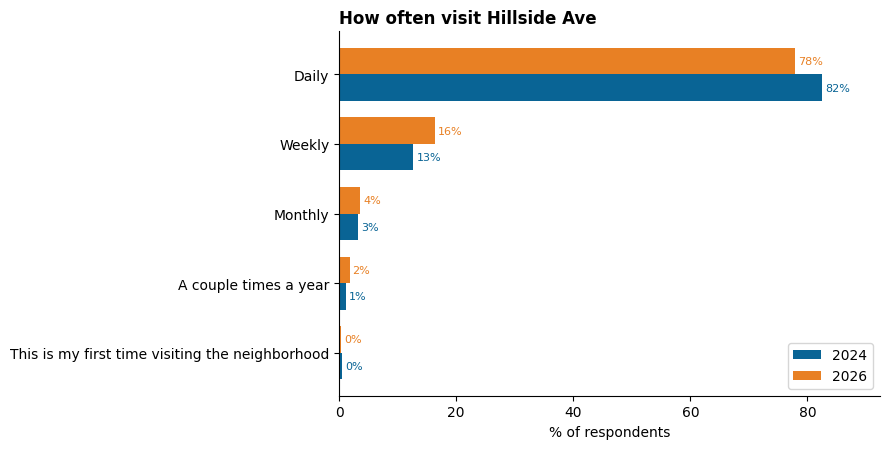

In [10]:
print("Available questions:")
for key, label, kind in S.QUESTIONS:
    print(f"  {key:14s} {label}")

def compare(key):
    kind = S.QKIND[key]
    if kind == "buslines":
        t = S.compare_buslines(df); col = "Line"
    elif kind == "multi":
        t = S.compare_multi(df, key); col = "Option"
    elif kind in ("single", "scale"):
        t = S.compare_single(df, key); col = "Category"
    else:
        print("Open-text question — see §8."); return
    plot_compare(t[col], t["2024 %"], t["2026 %"], S.QLABEL[key])
    return t

compare("often");  # <-- change the key to explore

## 10 · Key findings

1. **Satisfaction improved.** Net bus-trip satisfaction rose **+18 → +41**
   (+23 pts); dissatisfaction fell 28% → 20%.
2. **But bus-lane backlash grew.** Open-ended complaints tying congestion/tickets
   to the bus lane jumped **5% → 21%** — the fastest-rising theme.
3. **Ridership patterns shifted.** Q1 usage nearly doubled and Q2 rose while
   Q43/Q30 fell; subway access dropped 44% → 33% as walking rose.
4. **Wait time is the sticky issue.** "Waited too long" held at 25% — reliability
   remains the top actionable gap.
5. **Read pre/post with care.** The 2026 sample skews older and smaller; filter
   to a matched subgroup before attributing shifts to the bus lane.

### Related tools in this folder
- **`app.py`** — interactive Streamlit dashboard: `streamlit run app.py`
- **`report.py`** — one-click static HTML findings report: `python report.py`

*Generated from `hillside2024.csv` and `hillside2026.csv`; all figures trace to
`survey_lib.py`. Displayed values rounded.*